# Analisis Segmentasi Pelanggan (RFM & K-Means)

**Tujuan:** Notebook ini akan memandu Anda melalui seluruh proses analisis segmentasi pelanggan berdasarkan proposal proyek, mulai dari memuat data mentah hingga mengidentifikasi segmen pelanggan yang dapat ditindaklanjuti.

**Alur Kerja:**
1.  **Part 1: Data Loading & Preparation** - Menggabungkan semua file Excel dan menghitung metrik RFM.
2.  **Part 2: Exploratory Data Analysis (EDA) & Preprocessing** - Memahami, memvisualisasikan, dan mempersiapkan data RFM untuk clustering.
3.  **Part 3: K-Means Clustering** - Menemukan jumlah cluster yang optimal dan menerapkan algoritma K-Means.
4.  **Part 4: Cluster Analysis & Interpretation** - Menganalisis dan memberi nama setiap segmen pelanggan.

## Part 1: Data Loading & RFM Calculation

In [1]:
import pandas as pd
import glob
import os
import datetime as dt
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Mengatur agar semua kolom ditampilkan saat memanggil .head() atau .info()
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


**Load and Merge Transaction Data**
Kode ini akan mencari semua file Excel di folder `../dataset/`, membacanya, dan menggabungkannya menjadi satu DataFrame

In [2]:
path_ke_dataset = '../dataset/*.xlsx'
file_paths = glob.glob(path_ke_dataset)
if not file_paths:
  print("Tidak ada file Excel (.xlsx) yang ditemukan di folder dataset.")
else:
  print("Ditemukan {len(file_paths)} file untuk digabungkan:")
list_of_dataframes = []
for path in file_paths:
  try:
    print("- Membaca {os.path.basename(path)}...")
    df = pd.read_excel(path, skiprows=4)
    list_of_dataframes.append(df)
  except Exception as e:
    print("Error saat membaca file {path}: {e}")
 # Gabungkan semua dataframe
df_merged = pd.concat(list_of_dataframes, ignore_index=True)
print("Semua file berhasil digabungkan.")
print("Total baris data setelah digabung: {len(df_merged)}")
display(df_merged.head())

Ditemukan {len(file_paths)} file untuk digabungkan:
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
Semua file berhasil digabungkan.
Total baris data setelah digabung: {len(df_merged)}


,No.,Tgl. Trans.,No. Trans.,Syarat Bayar.,Tgl. Jatuh Tempo,Customer,Total (Rp),PPN (Rp),Biaya Kirim (Rp),Grand Total (Rp),No. SO,No. Konsinyasi,ISBN,ISBN Dtl.,Judul,Satuan,Jml,Harga (Rp),Total Disc (%),Total Disc (Rp),Subtotal (Rp),Catatan,Ekspedisi,No. Resi,Tgl. Kirim
0,1,2017-01-03,J.01.1701.0001,CASH,2017-01-03,YUNICA FITRIANI,30000.0,0.0,0.0,30000.0,NaN,NaN,9786021302217,9786021302217.099609,SOUL KEEPING (MENJAGA JIWA),EX,1.0,60000.0,50.0,30000.0,30000.0,NaN,NaN,NaN,NaN
1,2,2017-01-03,J.01.1701.0002,CASH,2017-01-03,MELINA,124000.0,0.0,0.0,124000.0,NaN,NaN,9786021854754,9786021854754.099609,BAHAN PA : MENCARI KEHENDAK TUHAN,EX,1.0,24000.0,NaN,0.0,24000.0,NaN,NaN,NaN,NaN
2,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9786021854716,9786021854716.099609,JUST DO SOMETHING (LAKUKANLAH SESUATU),EX,1.0,40000.0,NaN,0.0,40000.0,NaN,NaN,NaN,NaN
3,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9766029670097,9766029670097.099609,MEMBENTUK KEROHANIAN ANAK MUDA,EX,1.0,60000.0,NaN,0.0,60000.0,NaN,NaN,NaN,NaN
4,3,2017-01-03,J.01.1701.0003,7 HARI,2017-01-10,IWAN SATRIA,400000.0,0.0,45000.0,445000.0,NaN,NaN,9786021854761,9786021854761.099609,UANG DAN PEKERJAAN,EX,20.0,25000.0,20.0,5000.0,400000.0,NaN,NaN,NaN,NaN


### Calculate RFM Metrics
Membersihkan data transaksi dan mengubahnya menjadi tabel RFM (satu baris per pelanggan)

In [3]:
KOLOM_TANGGAL = 'Tgl. Trans.'
KOLOM_INVOICE = 'No. Trans.'
KOLOM_PELANGGAN = 'Customer'
KOLOM_TOTAL_BELANJA = 'Subtotal (Rp)'

# 1. Pilih kolom yang dibutuhkan dan bersihkan data
df_rfm_prep = df_merged[[KOLOM_TANGGAL, KOLOM_INVOICE, KOLOM_PELANGGAN, KOLOM_TOTAL_BELANJA]].copy()
df_rfm_prep.dropna(subset=[KOLOM_PELANGGAN, KOLOM_TANGGAL], inplace=True)
df_rfm_prep[KOLOM_TANGGAL] = pd.to_datetime(df_rfm_prep[KOLOM_TANGGAL], errors='coerce')
df_rfm_prep[KOLOM_TOTAL_BELANJA] = pd.to_numeric(df_rfm_prep[KOLOM_TOTAL_BELANJA], errors='coerce').fillna(0)
df_rfm_prep.dropna(subset=[KOLOM_TANGGAL], inplace=True)
print("Data berhasil dibersihkan.")

# 2. Hitung nilai RFM
snapshot_date = df_rfm_prep[KOLOM_TANGGAL].max() + dt.timedelta(days=1)
df_rfm = df_rfm_prep.groupby(KOLOM_PELANGGAN).agg({
KOLOM_TANGGAL: lambda date: (snapshot_date - date.max()).days,
KOLOM_INVOICE: 'nunique', # Menggunakan nunique untuk transaksi unik
KOLOM_TOTAL_BELANJA: 'sum'
})

# 3. Ganti nama kolom
df_rfm.rename(columns={
KOLOM_TANGGAL: 'Recency',
KOLOM_INVOICE: 'Frequency',
KOLOM_TOTAL_BELANJA: 'Monetary'
}, inplace=True)

# 4. Filter data yang tidak relevan (misal, pelanggan yang hanya retur atau tidak belanja)
df_rfm = df_rfm[df_rfm['Monetary'] > 0]

print(f"✅ Tabel RFM berhasil dibuat dengan {len(df_rfm)} pelanggan.")
display(df_rfm.head())

Data berhasil dibersihkan.
✅ Tabel RFM berhasil dibuat dengan 16499 pelanggan.


,Recency,Frequency,Monetary
Customer,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,343,6,1149000.0
(VONNI PERONICA),741,1,32500.0
(YEMIMA),846,1,58000.0
12345MAYKEL 230613A669JJWU,551,1,66990.0
180 CHRISTIAN STORE JAKARTA,13,34,2342650.0


### Part 2: Exploratory Data Analysis (EDA) & Preprocessing

### Analyze RFM Distribution
Memahami distribusi data. Apakah ada nilai yang sangat ekstrim (outliers)? Apakah datanya miring (skewed)? Ini penting karena K-Means sensitif terhadap kedua hal ini.

In [4]:
print("Ringkasan Statistik Data RFM:")
display(df_rfm.describe())

print("Skewness Data RFM:")
print(df_rfm.skew())

Ringkasan Statistik Data RFM:


,Recency,Frequency,Monetary
count,16499.000000,16499.000000,1.649900e+04
mean,1114.611370,1.724408,2.736444e+05
std,728.477879,6.174857,2.735948e+06
min,1.000000,1.000000,2.000000e+03
25%,500.000000,1.000000,5.044000e+04
50%,1045.000000,1.000000,6.405000e+04
75%,1614.000000,1.000000,1.020000e+05
max,2920.000000,383.000000,2.222586e+08


Skewness Data RFM:
Recency       0.424746
Frequency    34.918178
Monetary     45.624076
dtype: float64


### Visualize RFM Distribution
Visualisasi dengan Boxplot untuk melihat outliers. Titik-titik di luar "kumis" plot adalah outliers."

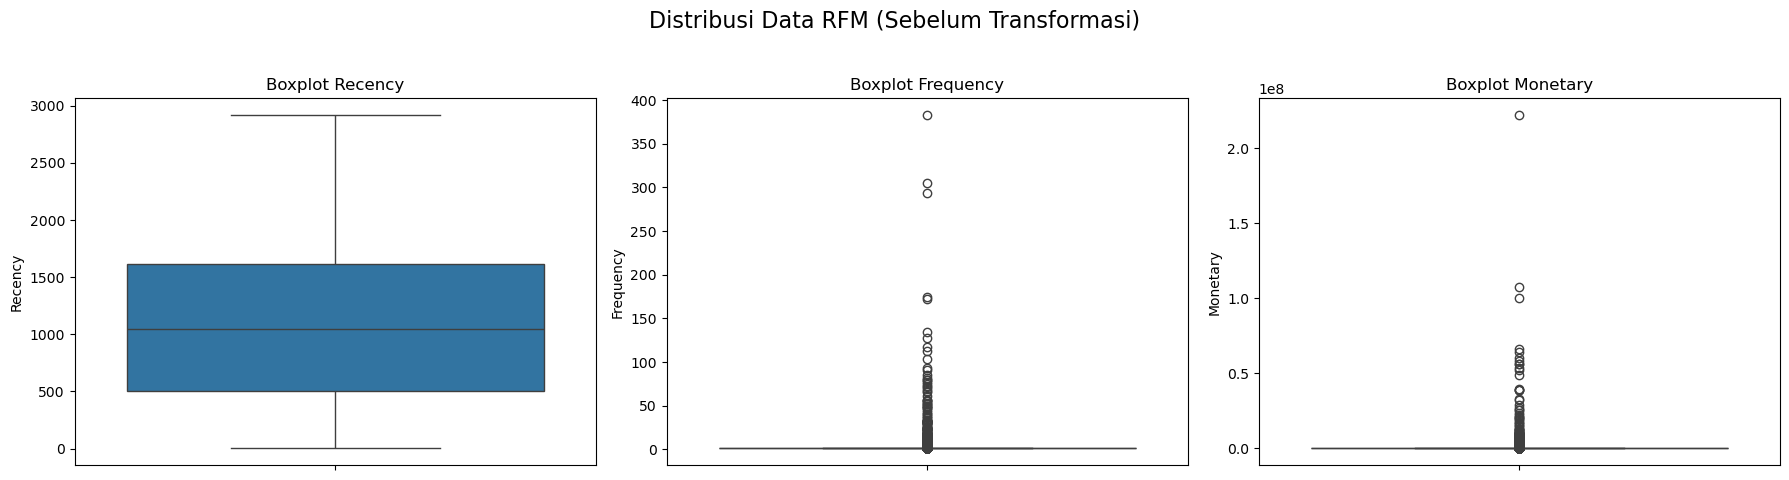

In [5]:
plt.figure(figsize=(18, 5))
plt.suptitle('Distribusi Data RFM (Sebelum Transformasi)', fontsize=16)

# Boxplot untuk Recency
plt.subplot(1, 3, 1)
sns.boxplot(y=df_rfm['Recency'])
plt.title('Boxplot Recency')

# Boxplot untuk Frequency
plt.subplot(1, 3, 2)
sns.boxplot(y=df_rfm['Frequency'])
plt.title('Boxplot Frequency')

# Boxplot untuk Monetary
plt.subplot(1, 3, 3)
sns.boxplot(y=df_rfm['Monetary'])
plt.title('Boxplot Monetary')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###  Data Transformation and Scaling
Karena data kita highly skewed dan memiliki skala yang berbeda, maka dilakukan:
1.  **Log Transformation**: Untuk mengurangi efek skewness dan outliers.
2.  **Standard Scaling**: Untuk membawa semua variabel ke skala yang sama (rata-rata 0, standar deviasi 1).

In [6]:
# 1. Log Transformation (tambah 1 untuk menghindari log(0))
df_rfm_log = np.log1p(df_rfm) 
# untuk menekan nilai-nilai yang sangat besar dan menarik outliers lebih dekat ke pusat data. Ini secara efektif akan mengurangi skewness dan membuat distribusi data Anda lebih simetris (mendekati kurva lonceng).

# 2. Standard Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log)

# Konversi hasil scaling kembali ke DataFrame
df_rfm_prepared = pd.DataFrame(rfm_scaled, index=df_rfm.index, columns=df_rfm.columns)

print("Data RFM berhasil ditransformasi dan di-scaling.")
display(df_rfm_prepared.head())

Data RFM berhasil ditransformasi dan di-scaling.


,Recency,Frequency,Monetary
Customer,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,-0.741374,2.922447,2.812270
(VONNI PERONICA),-0.036634,-0.368254,-0.956209
(YEMIMA),0.084703,-0.368254,-0.344026
12345MAYKEL 230613A669JJWU,-0.307820,-0.368254,-0.191720
180 CHRISTIAN STORE JAKARTA,-3.676538,7.150045,3.565242


## Part 3: K-Means Clustering

### Find Optimal Number of Clusters (Elbow Method)
Kita akan menjalankan K-Means untuk beberapa jumlah cluster (K) dan melihat di mana penambahan cluster baru tidak lagi memberikan banyak penurunan pada *inertia* (Within-Cluster Sum of Squares). Titik ini disebut "siku" (elbow).

Menghitung Inertia dan Silhouette Score untuk setiap K...
Untuk K=2, Silhouette Score adalah: 0.5707
Untuk K=3, Silhouette Score adalah: 0.4528
Untuk K=4, Silhouette Score adalah: 0.4503
Untuk K=5, Silhouette Score adalah: 0.3861
Untuk K=6, Silhouette Score adalah: 0.4107
Untuk K=7, Silhouette Score adalah: 0.4186
Untuk K=8, Silhouette Score adalah: 0.3635
Untuk K=9, Silhouette Score adalah: 0.3773
Untuk K=10, Silhouette Score adalah: 0.3586


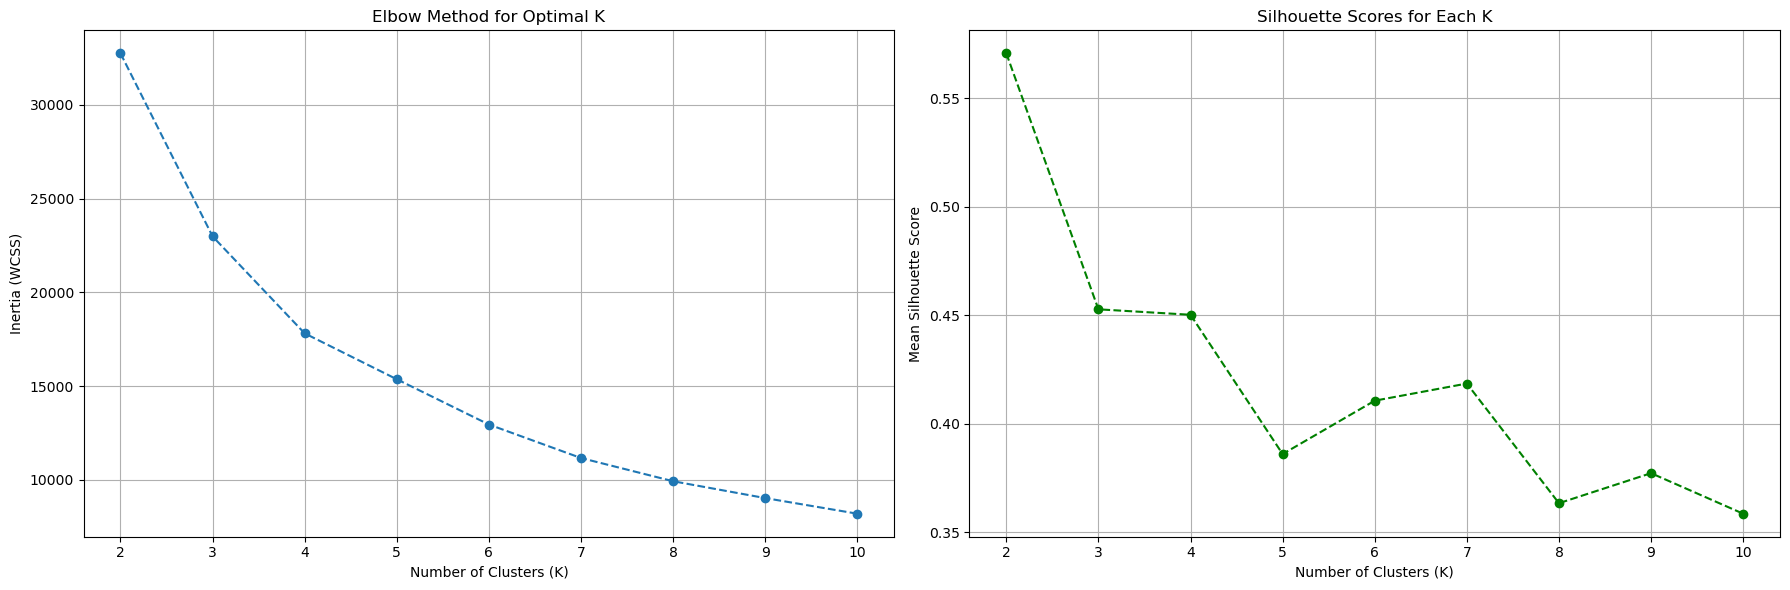

In [7]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
range_k = range(2, 11) # Mulai dari 2 karena silhouette butuh min. 2 cluster

print("Menghitung Inertia dan Silhouette Score untuk setiap K...")
for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rfm_prepared)
    
    # Hitung Inertia
    inertia.append(kmeans.inertia_)
    
    # Hitung Silhouette Score
    score = silhouette_score(df_rfm_prepared, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Untuk K={k}, Silhouette Score adalah: {round(score, 4)}")

# Buat plot
plt.figure(figsize=(18, 6))

# Plot 1: Elbow Method
plt.subplot(1, 2, 1)
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(range_k)
plt.grid(True)

# Plot 2: Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range_k, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Scores for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Mean Silhouette Score')
plt.xticks(range_k)
plt.grid(True)

plt.tight_layout()
plt.show()

### Apply K-Means Clustering
Berdasarkan grafik Elbow, kita akan memilih jumlah K yang optimal (biasanya 3, 4, atau 5 adalah pilihan yang baik untuk segmentasi RFM). Kemudian kita terapkan K-Means dengan K tersebut.

In [8]:
# Pilih K yang optimal dari grafik Elbow (misalnya, K=4)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_rfm_prepared)

# Tambahkan label cluster ke DataFrame RFM asli (yang belum di-scaling)
df_rfm['Cluster'] = kmeans.labels_

print(f"✅ Clustering selesai dengan K={optimal_k}.")
display(df_rfm.head())

✅ Clustering selesai dengan K=3.


,Recency,Frequency,Monetary,Cluster
Customer,,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,343,6,1149000.0,0
(VONNI PERONICA),741,1,32500.0,2
(YEMIMA),846,1,58000.0,2
12345MAYKEL 230613A669JJWU,551,1,66990.0,2
180 CHRISTIAN STORE JAKARTA,13,34,2342650.0,0


In [9]:
# Hitung jumlah pelanggan di setiap cluster dan urutkan berdasarkan nomor cluster
cluster_distribution = df_rfm['Cluster'].value_counts().sort_index()

print("\nDistribusi Pelanggan per Cluster:")
print(cluster_distribution)


Distribusi Pelanggan per Cluster:
Cluster
0     1713
1     3028
2    11758
Name: count, dtype: int64


C:\Users\asus\AppData\Local\Temp\ipykernel_18440\3495592881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df_rfm, palette='viridis')


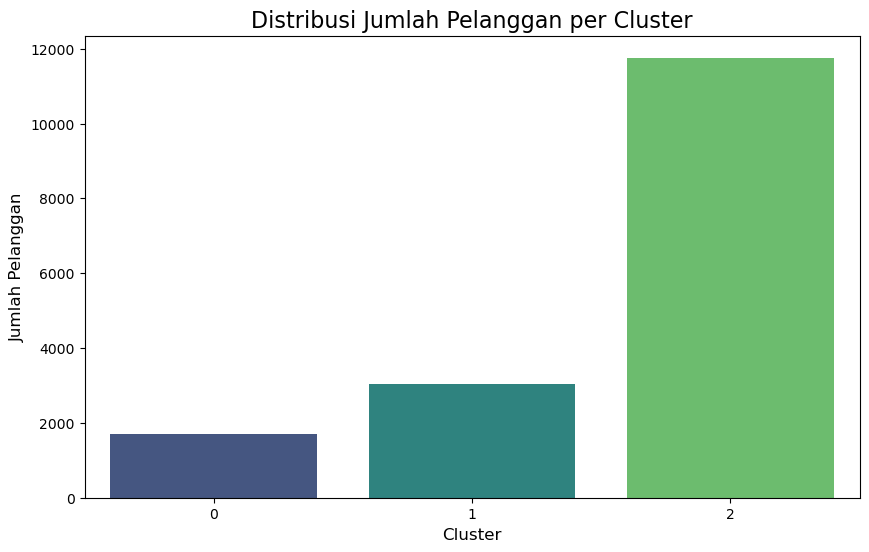

In [10]:
# Visualisasikan distribusi dengan bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=df_rfm, palette='viridis')
plt.title('Distribusi Jumlah Pelanggan per Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

# df_rfm_prepared adalah data yang sudah di-scaling yang Anda gunakan untuk K-Means
# kmeans.labels_ adalah hasil cluster dari setiap pelanggan

# Hitung Mean Silhouette Score
silhouette_avg = silhouette_score(df_rfm_prepared, kmeans.labels_)

print(f"Mean Silhouette Score untuk K={optimal_k} adalah: {silhouette_avg}")

Mean Silhouette Score untuk K=3 adalah: 0.45280090014392066


### Profile the Clusters
Memahami karakteristik setiap cluster. Kita akan menghitung rata-rata R, F, dan M untuk setiap cluster.

In [12]:
cluster_profile = df_rfm.groupby('Cluster').agg({
  'Recency': 'mean',
  'Frequency': 'mean',
  'Monetary': 'mean',
}).round(2)
    
print("Profil Rata-rata per Cluster:")
display(cluster_profile)

Profil Rata-rata per Cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,1183.65,6.97,1960488.62
1,184.51,1.05,83027.74
2,1344.08,1.13,76980.25


### Visualize the Clusters
Memvisualisasikan profil cluster supaya lebih mudah untuk dibandingkan.

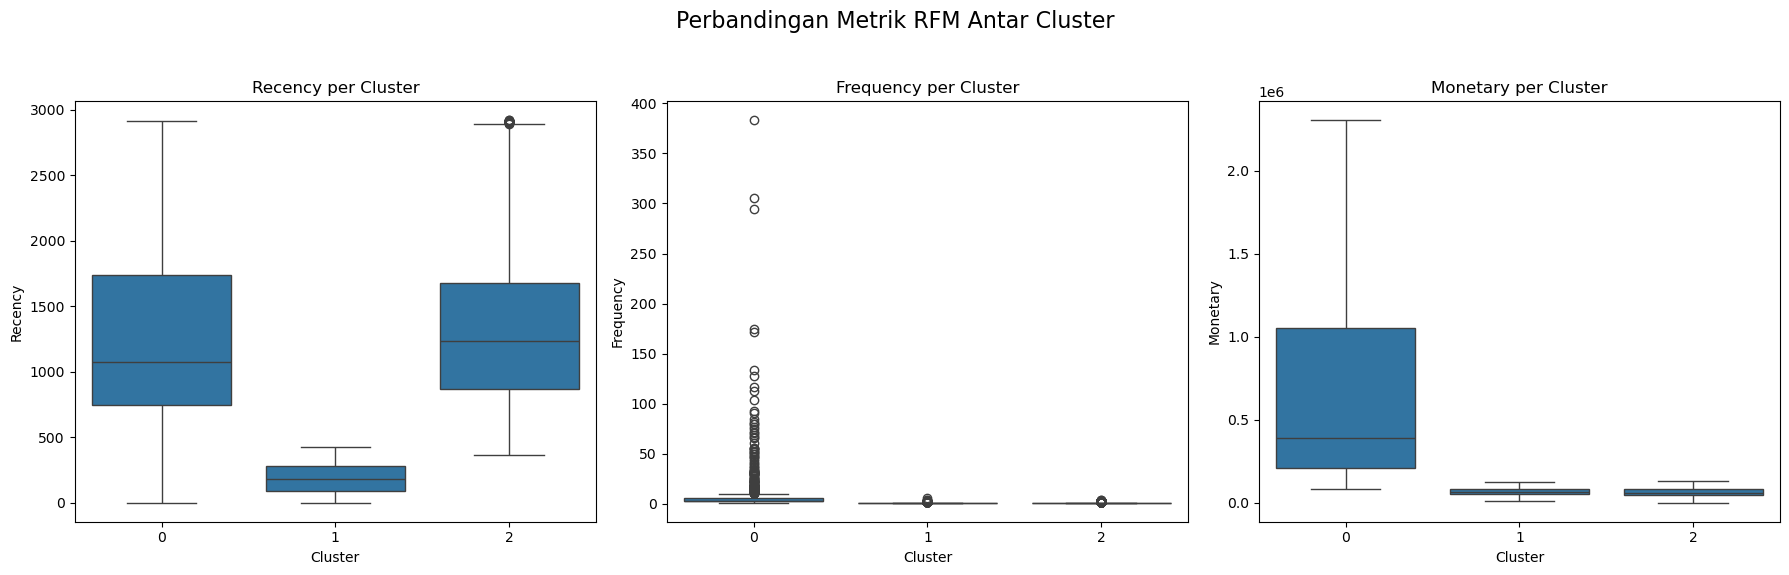

In [13]:
plt.figure(figsize=(18, 6))
plt.suptitle('Perbandingan Metrik RFM Antar Cluster', fontsize=16)

# Plot Recency
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Recency', data=df_rfm)
plt.title('Recency per Cluster')

# Plot Frequency
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Frequency', data=df_rfm)
plt.title('Frequency per Cluster')

# Plot Monetary
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Monetary', data=df_rfm, showfliers=False) # Hapus outliers agar lebih mudah dibaca
plt.title('Monetary per Cluster')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretasi dan Penamaan Segmen
Berdasarkan profil dan visualisasi, kita sekarang dapat memberi nama pada setiap segmen.
  - **Recency Rendah** = Baik (Baru saja belanja)
  - **Frequency Tinggi** = Baik (Sering belanja)
  - **Monetary Tinggi** = Baik (Banyak belanja)

Cluster 2: Pelanggan Juara (Champions)
Recency (80 hari): Sangat rendah. Mereka adalah pelanggan yang paling baru berinteraksi.

Frequency (12.6 kali): Sangat tinggi. Rata-rata, mereka bertransaksi hampir 13 kali!

Monetary (Rp 3.125.185): Sangat tinggi. Nilai belanja mereka jauh melampaui semua segmen lain.

Kesimpulan: Ini adalah pelanggan terbaik Anda. Mereka sering belanja, menghabiskan banyak uang, dan baru saja bertransaksi. Mereka adalah aset paling berharga.

Cluster 1: Pelanggan Setia (Loyal Customers)
Recency (378 hari): Cukup rendah. Mereka tergolong pelanggan yang masih aktif.

Frequency (2.3 kali): Menengah. Mereka sudah bertransaksi lebih dari sekali.

Monetary (Rp 147.202): Menengah. Nilai belanja mereka cukup baik.

Kesimpulan: Ini adalah pelanggan yang konsisten dan memiliki potensi besar. Mereka adalah fondasi yang stabil bagi bisnis Anda dan bisa "naik kelas" menjadi Pelanggan Juara.

Cluster 3: Pelanggan Berisiko Pindah (At-Risk)
Recency (961 hari): Cukup tinggi. Sudah lebih dari 2.5 tahun sejak transaksi terakhir mereka.

Frequency (1.3 kali): Sangat rendah. Mayoritas dari mereka mungkin hanya belanja satu kali.

Monetary (Rp 74.457): Rendah.

Kesimpulan: Pelanggan ini sudah lama "tertidur" dan berada di ambang batas untuk menjadi tidak aktif selamanya. Mereka membutuhkan perhatian khusus untuk diaktifkan kembali.

Cluster 0: Pelanggan Hilang (Churned / Lost Customers)
Recency (1925 hari): Sangat tinggi. Rata-rata, sudah lebih dari 5 tahun sejak mereka terakhir berbelanja.

Frequency (1.16 kali): Paling rendah. Hampir semuanya hanya pelanggan satu kali.

Monetary (Rp 62.946): Paling rendah.

Kesimpulan: Ini adalah segmen terbesar Anda yang terdiri dari pelanggan-pelanggan lama yang kemungkinan besar sudah tidak akan kembali.

### Trend Penjualan Berdasarkan Waktu (Monthly / Yearly Trend + Seasonality)

=== Seasonality (Bulan dengan Penjualan Tertinggi) ===


,Month,Subtotal (Rp)
9,10.0,4.402774e+08
11,12.0,4.373590e+08
10,11.0,4.336980e+08
8,9.0,3.931414e+08
1,2.0,3.743897e+08
2,3.0,3.716886e+08
0,1.0,3.697333e+08
7,8.0,3.604768e+08
6,7.0,3.563030e+08
3,4.0,3.527627e+08



 Bulan Puncak Penjualan (Top 3): [10.0, 12.0, 11.0]

=== Top Buku yang Terjual di Bulan Puncak ([10.0, 12.0, 11.0]) ===


,Judul,Subtotal (Rp)
127,NGBO,1.333076e+08
123,MENGHIDUPI INJIL & MENGINJILI HIDUP,1.033102e+08
60,GOSPEL WISDOM,9.405462e+07
82,KALIBRASI HATI (LIBERTY IN THE GOSPEL),8.478667e+07
101,LEARNING TO HOLD: AFTER MARRIAGE,6.117256e+07
22,BUKAN SEKADAR KATA-KATA,3.813934e+07
218,TUJUH LANGKAH MENYUSUN KHOTBAH YANG MENGUBAH K...,3.520608e+07
145,PERSPECTIVES JILID 1 & 2,3.138980e+07
172,SPIRITUAL FORMATION,2.956816e+07
44,EMOTIONALLY HEALTHY SPIRITUALITY,2.669650e+07


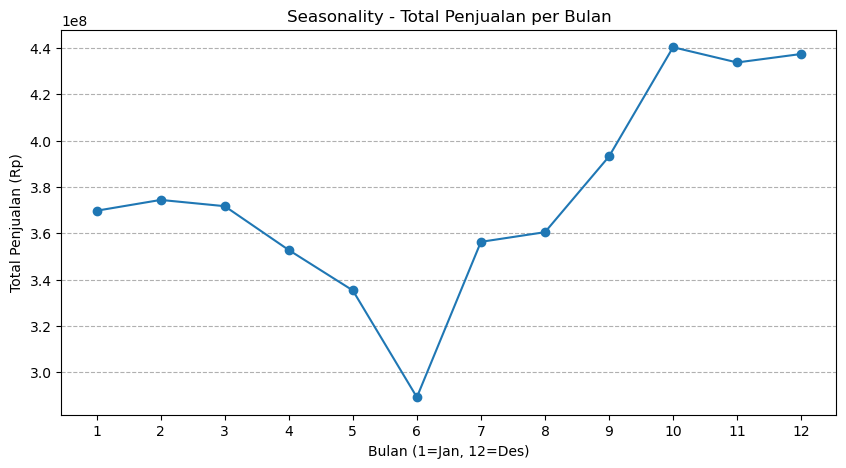

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df = df_merged.copy()

df["Tgl. Trans."] = pd.to_datetime(df["Tgl. Trans."], errors="coerce")
df["Month"] = df["Tgl. Trans."].dt.month

seasonality = (
    df.groupby("Month")["Subtotal (Rp)"]
      .sum()
      .reset_index()
      .sort_values(by="Subtotal (Rp)", ascending=False)

print("Seasonality (Bulan dengan Penjualan Tertinggi)")
display(seasonality)

top_n = 3
bulan_puncak = seasonality.head(top_n)["Month"].tolist()
print(f"\n Bulan Puncak Penjualan (Top {top_n}): {bulan_puncak}")

df_puncak = df[df["Month"].isin(bulan_puncak)]

top_books_in_peak = (
    df_puncak.groupby("Judul")["Subtotal (Rp)"]
    .sum()
    .reset_index()
    .sort_values(by="Subtotal (Rp)", ascending=False)
)

print(f"\nTop Buku yang Terjual di Bulan Puncak ({bulan_puncak})")
display(top_books_in_peak.head(10))

plt.figure(figsize=(10, 5))
seasonality_plot = seasonality.sort_values(by="Month") 
plt.plot(seasonality_plot["Month"], seasonality_plot["Subtotal (Rp)"], marker='o')
plt.title("Seasonality - Total Penjualan per Bulan")
plt.xlabel("Bulan (1=Jan, 12=Des)")
plt.ylabel("Total Penjualan (Rp)")
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--')
plt.show()

### Market Basket Analysis

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

df = df_merged.copy()

basket = (
    df.groupby(["No. Trans.", "Judul"])["Jml"]
      .sum()
      .unstack()
      .fillna(0)
)

basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_items = apriori(basket_binary, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

print("Frequent Itemsets")
display(frequent_items)

print("Association Rules")
display(rules[["antecedents", "consequents", "support", "confidence", "lift"]])


=== Frequent Itemsets ===


e:\anaconda3\envs\associate_data_scientists\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.034761,(THE SACRED SEARCH CU 6)
1,0.031362,(NOT A FAN CU 4)
2,0.023105,(THE EMOTIONALLY HEALTHY WOMAN)
3,0.022619,(MENGHIDUPI INJIL & MENGINJILI HIDUP)


=== Association Rules ===


,antecedents,consequents,support,confidence,lift


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

df = df_merged.copy()

basket = (
    df.groupby(["No. Trans.", "Judul"])["Jml"]
      .sum()
      .unstack()
      .fillna(0)
)
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_items = apriori(basket_binary, min_support=0.001, use_colnames=True)

print("Frequent Itemsets (min_support 0.001)")
multi_item_sets = frequent_items[frequent_items['itemsets'].apply(lambda x: len(x) > 1)]

if multi_item_sets.empty:
    print("Kegagalan Analisis: Dengan min_support 0.001, tidak ada pasangan buku yang ditemukan.")
else:
    print(f"Ditemukan {len(multi_item_sets)} itemset dengan 2 item atau lebih.")
    display(multi_item_sets.head())


rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

print("\nAssociation Rules Ditemukan")
if rules.empty:
    print("Kegagalan Aturan: Tidak ada aturan yang memenuhi ambang batas lift 1.0.")
    print("Solusi: Coba Analisis Berdasarkan Kategori Buku (Genre) sebagai ganti Judul.")
else:
    strong_rules = rules[
        (rules['lift'] >= 1.5) & 
        (rules['confidence'] >= 0.1)
    ].sort_values(by=['confidence', 'lift'], ascending=False)
    
    print(f"Ditemukan {len(rules)} total aturan. Menampilkan {len(strong_rules)} aturan terkuat (Lift>=1.5, Confidence>=0.1):")
    display(strong_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

e:\anaconda3\envs\associate_data_scientists\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


=== Frequent Itemsets (dengan min_support 0.001) ===
Kegagalan Analisis: Dengan min_support 0.001, tidak ada pasangan buku yang ditemukan.

=== Association Rules Ditemukan ===
Kegagalan Aturan: Tidak ada aturan yang memenuhi ambang batas lift 1.0.
Solusi: Coba Analisis Berdasarkan Kategori Buku (Genre) sebagai ganti Judul.


### Analisa Pelanggan One-Time Buyers (Single Transaction Customers)

In [ ]:
df = df_merged.copy()

customer_txn_count = df.groupby("Customer")["No. Trans."].nunique()

one_time_customers = customer_txn_count[customer_txn_count == 1].index

df_one_time = df[df["Customer"].isin(one_time_customers)]

popular_books_one_time = (
    df_one_time.groupby("Judul")["Jml"]
               .sum()
               .sort_values(ascending=False)
)

print("Daftar Customer One-Time Buyers")
display(one_time_customers)

print("Buku yang Paling Banyak Dibeli One-Time Buyers")
display(popular_books_one_time.head(10))


=== Daftar Customer One-Time Buyers ===


Index(['(GRAMI) KEZIA ENDHY', '(VONNI PERONICA)', '(YEMIMA)',
       '12345MAYKEL 230613A669JJWU', '23053167N1URXQ SHARINTRINITA',
       '2305316PYUXUPD EP_PETRUS', '2306017E0DYMF6 SHARINTRINITA',
       '23060184A2PD7C CALVINWU27', '2306018B6JYA0V SURYA.KWOK',
       '230602BPY86TDU ZEVIEL',
       ...
       'ZEFANYA SHR', 'ZEFRI', 'ZEILA MUTIARA,', 'ZELINA O', 'ZENIA',
       'ZEVANYA', 'ZHILBY', 'ZIPORA AGUSTINA', 'ZONDERVAN PUBLISHING',
       'ZV0DW5NI8J 230608TF91T1Y9'],
      dtype='object', name='Customer', length=13635)

=== Buku yang Paling Banyak Dibeli One-Time Buyers ===


Judul
MENGHIDUPI INJIL & MENGINJILI HIDUP                               2385.0
NGBO                                                              1996.0
JESUS AMONG SECULAR GODS (YESUS DI ANTARA ALLAH-ALLAH SEKULAR)    1605.0
NOT A FAN CU 4                                                     830.0
THE SACRED SEARCH CU 6                                             825.0
EMOTIONALLY HEALTHY SPIRITUALITY                                   607.0
THE EMOTIONALLY HEALTHY WOMAN                                      591.0
UANG DAN PEKERJAAN                                                 526.0
REDISCOVERING DISCIPLESHIP                                         493.0
BAHAN PA : MENCARI KEHENDAK TUHAN                                  492.0
Name: Jml, dtype: float64